In [1]:
import duckdb
import pandas as pd
import sklearn


# connect to DuckDB file
con = duckdb.connect('../dbt_project/ecommerce.duckdb', read_only=True)

# preview to confirm it’s working
orders_df = con.execute("SELECT * FROM fct_orders LIMIT 5").fetchdf()
orders_df


,order_id,customer_id,order_status,order_purchase_ts,estimated_delivery_date,num_products,order_value,freight_cost
0,f848643eec1d69395095eb3840d2051e,4fa1cd166fa598be6de80fa84eaade43,delivered,2018-03-15 08:52:40,2018-03-29,1,79.989998,8.91
1,2807d0e504d6d4894d41672727bc139f,72ae281627a6102d9b3718528b420f8a,delivered,2018-02-03 20:37:35,2018-02-21,1,9.500000,7.78
2,b276e4f8c0fb86bd82fce576f21713e0,cf8ffeddf027932e51e4eae73b384059,delivered,2018-07-29 23:34:51,2018-08-06,1,179.000000,9.41
3,d17dc4a904426827ca80f2ccb3a6be56,569cf68214806a39acc0f39344aea67f,delivered,2017-05-14 20:28:25,2017-06-12,1,36.900002,17.92
4,a6cd683d4bd3b9b1f0aa37b27f8116d3,48f239e15744ed5e7ffbafc6bb6e882b,delivered,2017-01-28 23:45:53,2017-03-10,1,589.900024,20.00


In [2]:
# query to pull in the cleaned data from our fct and dim tables
cltv_query = """
SELECT
  c.customer_unique_id,
  COUNT(DISTINCT o.order_id) AS num_orders,
  SUM(o.order_value) AS cltv,
  AVG(o.order_value) AS avg_order_value,
  MIN(o.order_purchase_ts) AS first_order,
  MAX(o.order_purchase_ts) AS last_order,
  DATE_DIFF('day', MIN(o.order_purchase_ts), MAX(o.order_purchase_ts)) AS tenure_days,
  DATE_DIFF('day', MAX(o.order_purchase_ts), (SELECT MAX(order_purchase_ts) FROM fct_orders)) AS recency_days
FROM
  fct_orders o
JOIN
  dim_customers c
    ON o.customer_id = c.customer_id
WHERE
  o.order_value IS NOT NULL
GROUP BY
  c.customer_unique_id
"""


In [3]:
# add cleaned data to dataframe
cltv_df = con.execute(cltv_query).fetchdf()

# cleanup
cltv_df['first_order'] = pd.to_datetime(cltv_df['first_order'])
cltv_df['last_order'] = pd.to_datetime(cltv_df['last_order'])

# preview
cltv_df.head()


,customer_unique_id,num_orders,cltv,avg_order_value,first_order,last_order,tenure_days,recency_days
0,76b029c87118a29f2e3de420f5ec2fa2,1,340.630005,340.630005,2017-12-28 10:45:14,2017-12-28 10:45:14,0,293
1,4bc7250d4b42b3374eb6f41b12429592,1,239.000000,239.000000,2017-02-06 16:49:19,2017-02-06 16:49:19,0,618
2,f34cd7fd85a1f8baff886edf09567be3,4,1047.000000,261.750000,2017-08-22 12:49:28,2017-09-23 19:56:00,32,389
3,5bd72a5ba72683010f8385cff8bb92fd,1,29.500000,29.500000,2018-01-21 10:11:55,2018-01-21 10:11:55,0,269
4,99e36749c5c84dc56b13138caac13b55,1,38.900002,38.900002,2018-06-03 10:59:14,2018-06-03 10:59:14,0,136


In [4]:
# validation checks
cltv_df.info()
cltv_df.describe()
cltv_df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  95420 non-null  object        
 1   num_orders          95420 non-null  int64         
 2   cltv                95420 non-null  float64       
 3   avg_order_value     95420 non-null  float64       
 4   first_order         95420 non-null  datetime64[us]
 5   last_order          95420 non-null  datetime64[us]
 6   tenure_days         95420 non-null  int64         
 7   recency_days        95420 non-null  int64         
dtypes: datetime64[us](2), float64(2), int64(3), object(1)
memory usage: 5.8+ MB


customer_unique_id    0
num_orders            0
cltv                  0
avg_order_value       0
first_order           0
last_order            0
tenure_days           0
recency_days          0
dtype: int64

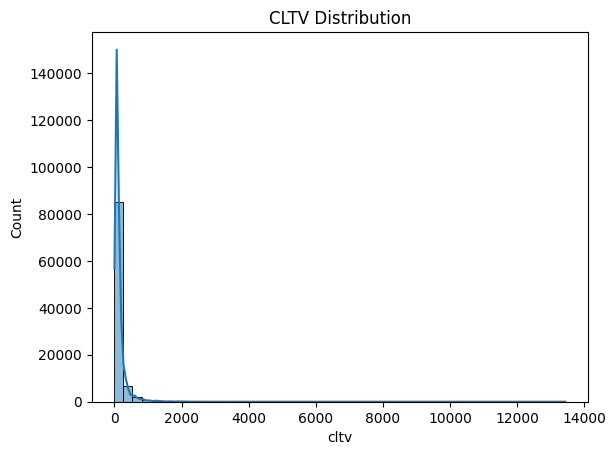

In [5]:
# quick viz for addtl validation check
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(cltv_df['cltv'], bins=50, kde=True)
plt.title("CLTV Distribution")
plt.show()


In [6]:
# select features
features = ['num_orders', 'avg_order_value', 'tenure_days', 'recency_days']
# independent variable
X = cltv_df[features]
# target variable
y = cltv_df['cltv']   


In [7]:
# train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train) 

# coefficients and intercept
for feat, coef in zip(X_train.columns, lr.coef_):
    print(f"{feat}: {coef:.2f}")

print(f"Intercept: {lr.intercept_:.2f}")


num_orders: 119.19
avg_order_value: 1.02
tenure_days: 0.03
recency_days: 0.00
Intercept: -121.20


In [15]:
# predict on test data
y_pred = lr.predict(X_test)

# evaluate the model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# print outputs
print("Model Performance on Test Set:")
print(f"MAE : ${mae:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"R² : {r2:.4f}")


Model Performance on Test Set:
MAE : $3.96
RMSE : $25.04
R² : 0.9852


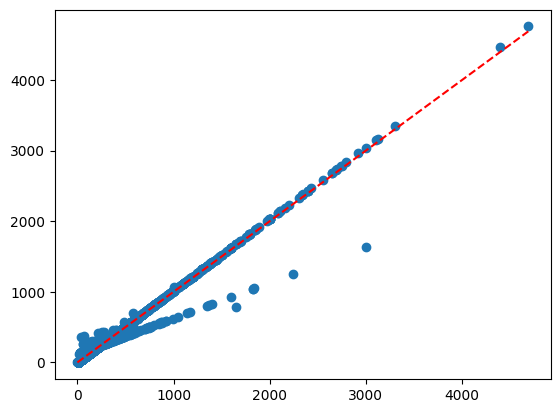

In [16]:
# plot actual vs predicted
plt.scatter(y_test, y_pred)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')


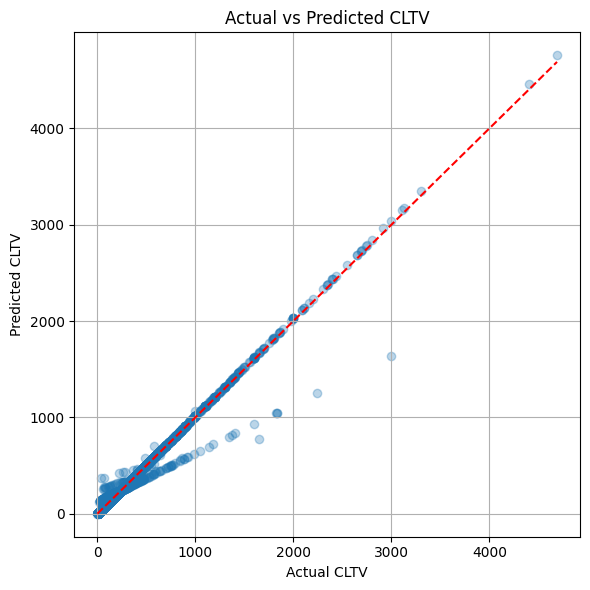

In [22]:
# create nicer plot to save and add to README
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel("Actual CLTV")
plt.ylabel("Predicted CLTV")
plt.title("Actual vs Predicted CLTV")
plt.grid(True)
plt.tight_layout()

plt.savefig("outputs/actual_vs_predicted_lr.png")
plt.show()

